# 04 - Explainable AI (XAI) with SHAP

Analisi dell'interpretabilità del modello Random Forest sul dataset Macro-Bond

In [ ]:
%pip install shap

In [4]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
# Evitiamo warning fastidiosi
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Carichiamo il Dataset e ricreiamo il target

df= pd.read_csv('./data/df_bond_macro_lagged.csv', index_col=0).reset_index()

if 'index' in df.columns:
    df = df.rename(columns={'index': 'isincode'})

df['referencedate'] = pd.to_datetime(df['referencedate'])

FORECAST_HORIZON = 30
df = df.sort_values(by=['isincode', 'referencedate']).reset_index(drop=True)
df['ytm_target'] = df.groupby('isincode')['Yield_to_Maturity'].shift(-FORECAST_HORIZON)
df = df.dropna(subset=['ytm_target']).copy()
df['target'] = (df['ytm_target'] < df['Yield_to_Maturity']).astype(int)



In [6]:
# Selezione del test
# Vogliamo spiegare le previsioni fatte sull'ultimo periodo di test (Out-of-Sample)

unique_dates = np.sort(df['referencedate'].unique())
n_splits = 5
test_size_days = len(unique_dates) // (n_splits + 1)

# Calcoliamo gli indici solo per il Fold 5 (indice 4 nel ciclo for)
fold = 4
test_start_idx = len(unique_dates) - test_size_days * (n_splits - fold)
test_end_idx = test_start_idx + test_size_days
test_dates = unique_dates[test_start_idx:test_end_idx]

df_test = df[df['referencedate'].isin(test_dates)].copy()

In [ ]:
# Isoliamo le features e il target
cols_to_exclude = ['marketcode', 'referencedate', 'pricetype', 'ytm_target', 'target', 'redemptiondate', 'description', 'isincode']
feature_cols = [col for col in df.columns if col not in cols_to_exclude]

X_test_raw = df_test[feature_cols]

print(f"Test Set isolato: {X_test_raw.shape[0]} righe, {X_test_raw.shape[1]} features.")

# Carichiamo la Pipeline salvata dal Notebook 3B
print("Caricamento modello Random Forest...")
pipeline = joblib.load('./data/best_rf_bonds_macro_model.pkl')

# Spacchettiamo la pipeline

scaler = pipeline.named_steps['scaler']
rf_model = pipeline.named_steps['rf']

# Scaliamo i dati di test
X_test_scaled_array = scaler.transform(X_test_raw)

# Ricreiamo un DataFrame Pandas con i dati scalati per non perdere i nomi delle features nei grafici SHAP!
X_test_shap = pd.DataFrame(X_test_scaled_array, columns=feature_cols, index=df_test.index)

Test Set isolato: 32309 righe, 70 features.
Caricamento modello Random Forest...


## Inizializzazione TreeSHAP

In [8]:
# Inizializziamo il treeExplainer
explainer = shap.TreeExplainer(rf_model)

# Calcoliamo i valori SHAP per il test set scalato
shap_values = explainer.shap_values(X_test_shap)

# Essendo una classificazione binaria, SHap restituisce i valori per entrambe le classi
# ma a noi interessa solo la classe 1 ovvero "Compra"

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1] # versioni precedenti di shap
elif len(shap_values.shape) == 3:
    shap_values_class_1 = shap_values[:, :, 1] # versioni più recenti di shap
else:
    shap_values_class_1 = shap_values # fallback, se non è una lista o un array 3D

## Analisi globale

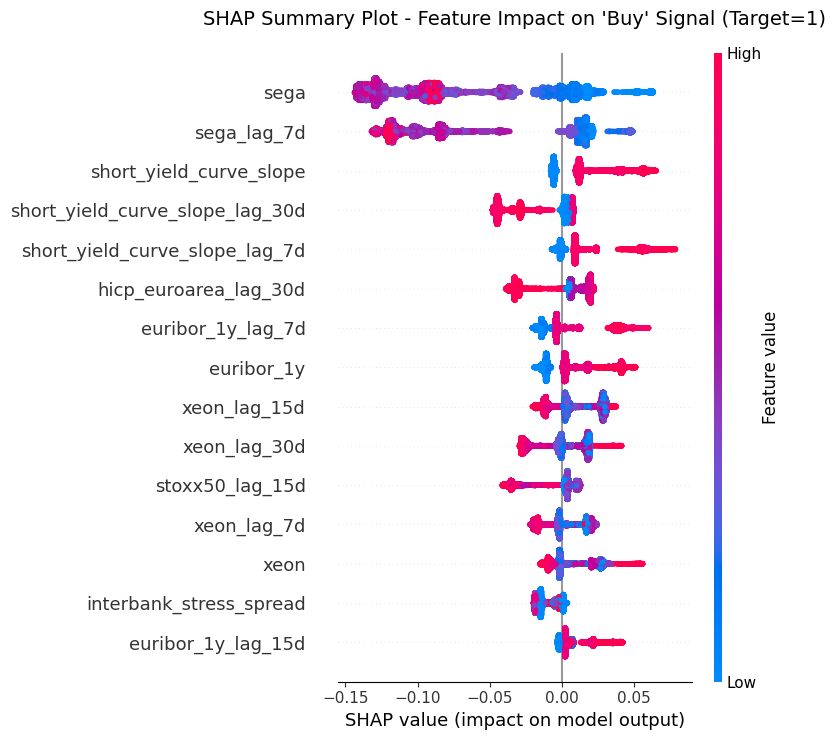

In [9]:
# Il Summary Plot mostra l'impatto di ogni feature sulla decisione del modello.
plt.figure(figsize=(10, 8))

# max_display=15 limita il grafico alle 15 variabili più influenti per renderlo leggibile
shap.summary_plot(shap_values_class_1, X_test_shap, max_display=15, show=False)

plt.title("SHAP Summary Plot - Feature Impact on 'Buy' Signal (Target=1)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


## Analisi locale

Analizziamo l'isin IT0005433195 in data 2026-01-09 
Probabilità prevista di 'Buy' 96.21%


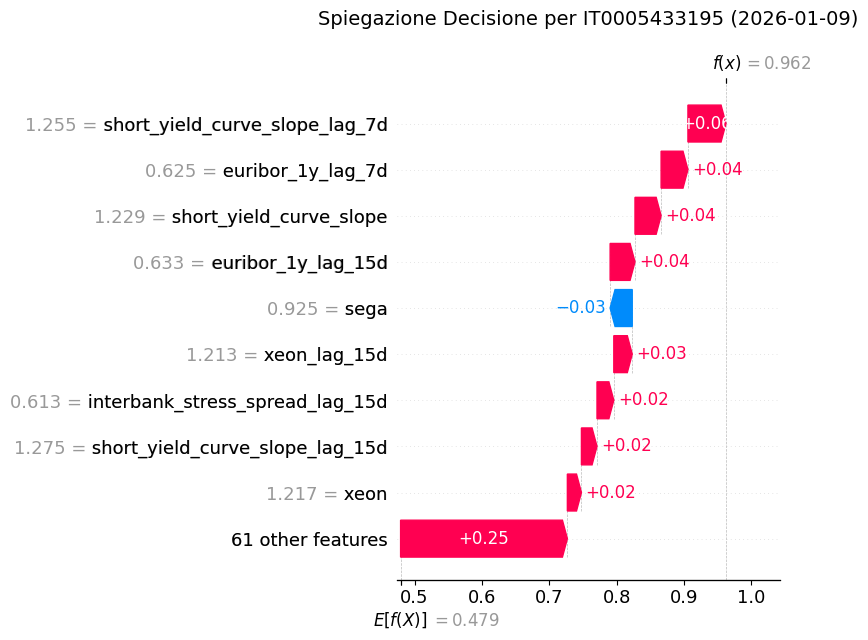

In [10]:
# calcoliamo tutte le probabilità sul test set
probs = rf_model.predict_proba(X_test_scaled_array)[:,1]

# Troviamo la riga in che ha maggiore probabilità
best_idx = np.argmax(probs)
best_isincode = df_test.iloc[best_idx]['isincode']
best_date = df_test.iloc[best_idx]['referencedate'].strftime('%Y-%m-%d')
best_prob = probs[best_idx]

print(f"Analizziamo l'isin {best_isincode} in data {best_date} ")
print(f"Probabilità prevista di 'Buy' {best_prob:.2%}")

# Estraiamo la probabilità media di base del modello
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

# Creiamo un oggetto "Explanation" richiesto dalle nuove versioni di SHAP per il Waterfall
shap_exp = shap.Explanation(values=shap_values_class_1[best_idx],
                            base_values=base_value,
                            data=X_test_shap.iloc[best_idx].values,
                            feature_names=feature_cols)

plt.figure(figsize=(10, 6))

# max_display=10 mostra i 10 fattori più impattanti, raggruppando gli altri in "Other"
shap.plots.waterfall(shap_exp, max_display=10, show=False)

plt.title(f"Spiegazione Decisione per {best_isincode} ({best_date})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()